In [30]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Data Loader

In [14]:
transform = transforms.Compose([
    transforms.ToTensor()
])

# Use MNIST / FashionMNIST
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_id = datasets.MNIST('./data', train=False, transform=transform)
test_ood = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
id_loader = DataLoader(test_id, batch_size=128)
ood_loader = DataLoader(test_ood, batch_size=128)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.80MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.22MB/s]


## VAE Model

In [15]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(64*7*7, 64)
        self.fc_logvar = nn.Linear(64*7*7, 64)

        self.fc_dec = nn.Linear(64, 64*7*7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1), nn.Sigmoid()
        )

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparam(mu, logvar)

        recon = self.decoder(self.fc_dec(z).view(-1,64,7,7))
        return recon, mu, logvar

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Loss Function

In [16]:
def loss_fn(x, recon, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

## Model Training

In [17]:
print("Training...")
for epoch in range(3):   # we have take small-set of data to train the model
    model.train()
    for x,_ in train_loader:
        x = x.to(device)

        recon, mu, logvar = model(x)
        loss = loss_fn(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} done")

Training...
Epoch 0 done
Epoch 1 done
Epoch 2 done


## Compute the likelihood

In [20]:
def compute_scores(loader):
    model.eval()
    scores = []

    with torch.no_grad():
        for x,_ in loader:
            x = x.to(device)

            recon, mu, logvar = model(x)

            # per-sample reconstruction loss
            recon_loss = F.binary_cross_entropy(
                recon, x, reduction='none'
            ).view(x.size(0), -1).sum(dim=1)

            # per-sample KL
            kl = -0.5 * torch.sum(
                1 + logvar - mu.pow(2) - logvar.exp(),
                dim=1
            )

            elbo = -(recon_loss + kl)

            scores.extend(elbo.cpu().numpy())

    return scores

## Figure 1: Likelihood Failure

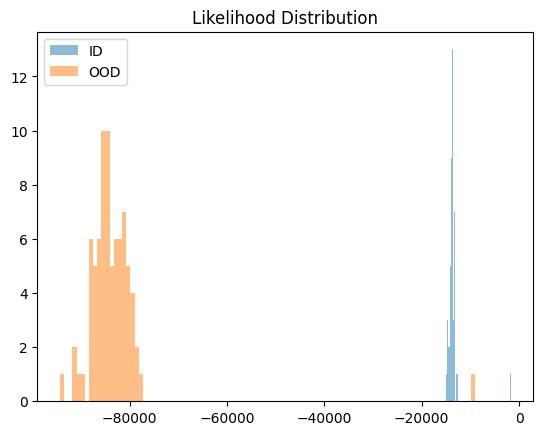

In [24]:
plt.figure()
plt.hist(id_scores, bins=100, alpha=0.5, label='ID')
plt.hist(ood_scores, bins=100, alpha=0.5, label='OOD')
plt.legend()
plt.title("Likelihood Distribution")

plt.savefig("likelihood_plot.png", dpi=300)
plt.show()

## Likelihood Regret

In [38]:
def likelihood_regret(x):
    model.eval()
    x = x.to(device)

    try:
        with torch.no_grad():
            recon, mu, logvar = model(x)

            recon_loss = F.binary_cross_entropy(
                recon, x, reduction='none'
            ).view(x.size(0), -1).sum(dim=1)

            kl = -0.5 * torch.sum(
                1 + logvar - mu.pow(2) - logvar.exp(),
                dim=1
            )

            original = -(recon_loss + kl)

        mu_opt = mu.detach().clone().requires_grad_(True)
        logvar_opt = logvar.detach().clone()

        optimizer = torch.optim.Adam([mu_opt], lr=1e-2)

        for _ in range(5):
            z = mu_opt
            recon = model.decoder(model.fc_dec(z).view(-1,64,7,7))

            recon_loss = F.binary_cross_entropy(
                recon, x, reduction='none'
            ).view(x.size(0), -1).sum(dim=1)

            kl = -0.5 * torch.sum(
                1 + logvar_opt - mu_opt.pow(2) - logvar_opt.exp(),
                dim=1
            )

            loss = (recon_loss + kl).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        optimized = -(recon_loss + kl)

        return (optimized - original).mean().item()

    except Exception as e:
        print("LR ERROR:", e)
        return None

In [39]:
lr_id = []
lr_ood = []

print("Computing LR...")

# ID
for x,_ in id_loader:
    x = x.to(device)

    for i in range(x.size(0)):
        val = likelihood_regret(x[i].unsqueeze(0))

        if val is not None:
            lr_id.append(val)

        if len(lr_id) >= 100:
            break
    if len(lr_id) >= 100:
        break

# OOD
for x,_ in ood_loader:
    x = x.to(device)

    for i in range(x.size(0)):
        val = likelihood_regret(x[i].unsqueeze(0))

        if val is not None:
            lr_ood.append(val)

        if len(lr_ood) >= 100:
            break
    if len(lr_ood) >= 100:
        break

print("FINAL LENGTHS:", len(lr_id), len(lr_ood))

Computing LR...
FINAL LENGTHS: 100 100


## Figure 02: Likelihood Regret

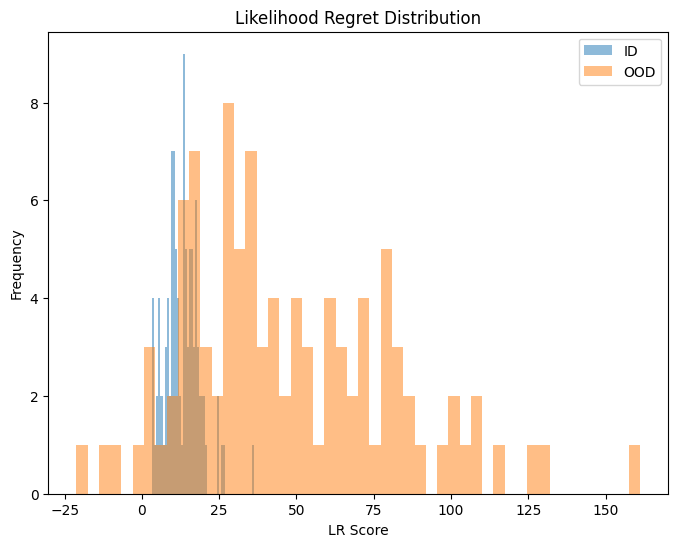

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(lr_id, bins=50, alpha=0.5, label='ID')
plt.hist(lr_ood, bins=50, alpha=0.5, label='OOD')

plt.legend()
plt.title("Likelihood Regret Distribution")
plt.xlabel("LR Score")
plt.ylabel("Frequency")

plt.savefig("lr_plot.png", dpi=300)
plt.show()

## Comparing Above Metrics to Clipped Robutness Metric

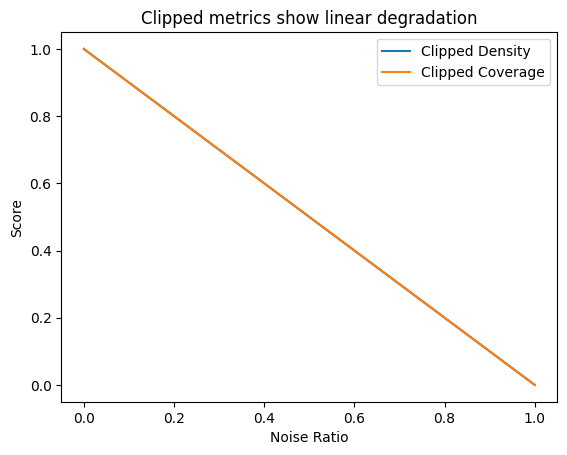

In [42]:
plt.figure()

plt.plot(ratios, cd_scores, label='Clipped Density')
plt.plot(ratios, cc_scores, label='Clipped Coverage')

plt.legend()
plt.xlabel("Noise Ratio")
plt.ylabel("Score")
plt.title("Clipped metrics show linear degradation")

plt.savefig("robustness_plot.png", dpi=300)
plt.show()